# 지도학습_다중회귀분석_고객별연간지출액예측

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [62]:
data = pd.read_csv("./data/ecommerce.csv")
data.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [64]:
data.isna().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [65]:
data.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


<Axes: >

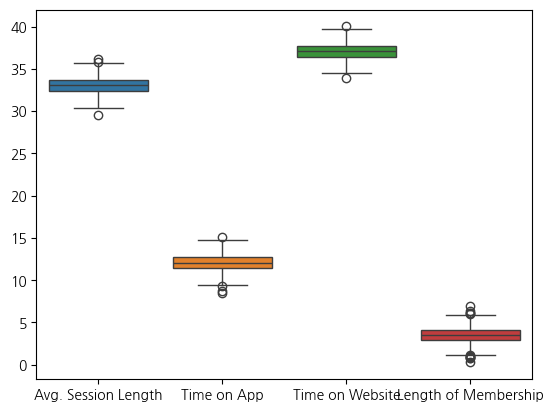

In [66]:
sns.boxplot(data.drop('Yearly Amount Spent', axis=1))

In [67]:
data = data.drop(['Email', 'Address', 'Avatar'], axis=1)
data

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092
...,...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573,573.847438
496,34.702529,11.695736,37.190268,3.576526,529.049004
497,32.646777,11.499409,38.332576,4.958264,551.620145
498,33.322501,12.391423,36.840086,2.336485,456.469510


In [68]:
data.columns[:-1]

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership'],
      dtype='object')

In [69]:
cols = data.columns[:-1]

============================ Avg. Session Length ============================


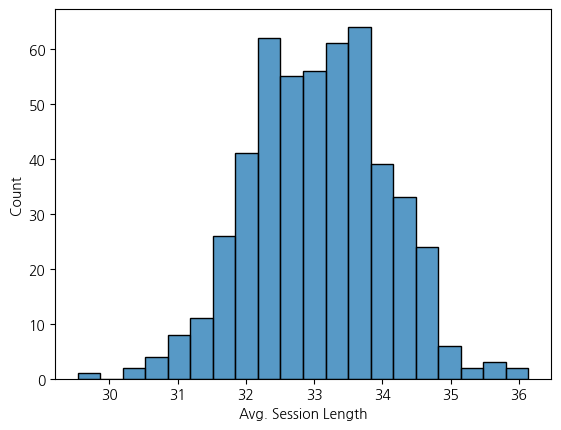


============================ Time on App ============================


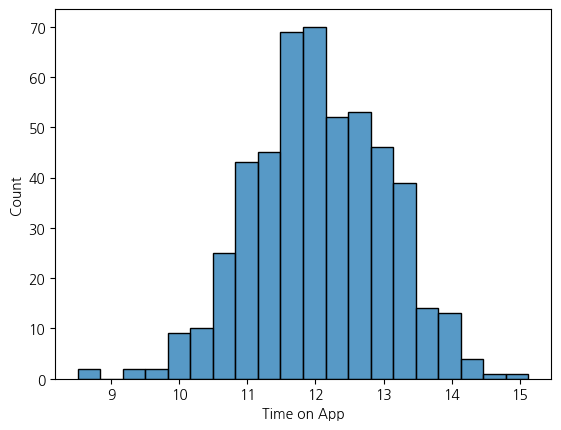


============================ Time on Website ============================


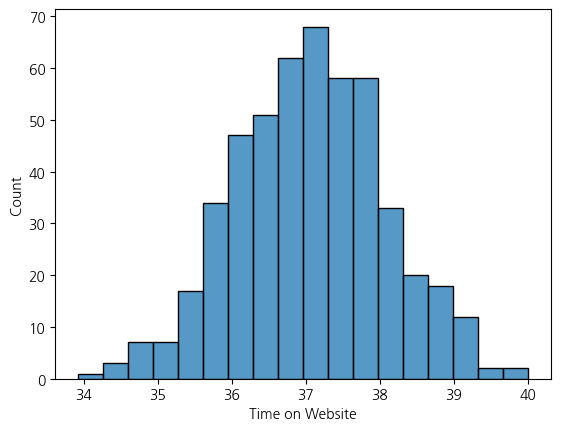


============================ Length of Membership ============================


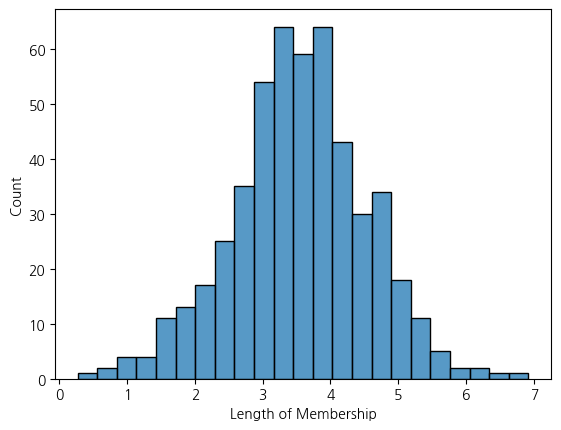

In [70]:
for col in cols:
    print("="*28, col , "="*28)
    sns.histplot(data[col])
    plt.show()
    print()

In [71]:
data.corr()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


<Axes: >

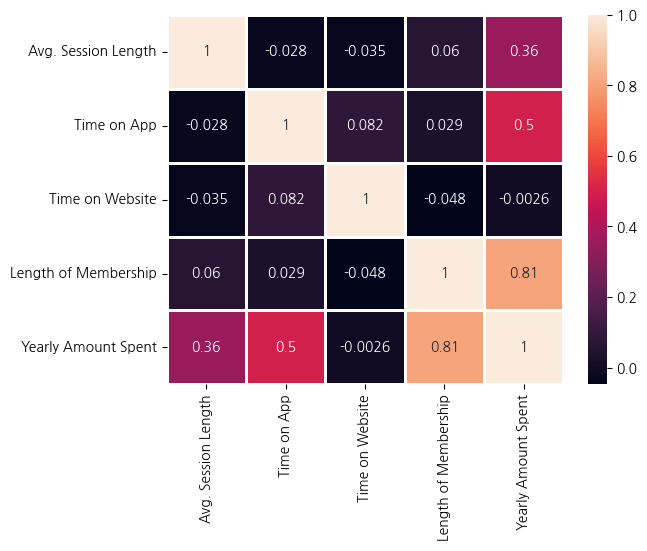

In [72]:
sns.heatmap(data.corr(), annot=True, linewidth=1)

# 데이터 홀드아웃, 스케일링, 분석

In [73]:
data.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [74]:
X = data.drop('Yearly Amount Spent', axis=1)
y = data['Yearly Amount Spent']

In [75]:
X

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573
496,34.702529,11.695736,37.190268,3.576526
497,32.646777,11.499409,38.332576,4.958264
498,33.322501,12.391423,36.840086,2.336485


In [76]:
y

0      587.951054
1      392.204933
2      487.547505
3      581.852344
4      599.406092
          ...    
495    573.847438
496    529.049004
497    551.620145
498    456.469510
499    497.778642
Name: Yearly Amount Spent, Length: 500, dtype: float64

# 데이터 홀드아웃

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standard Scaler로 독립변수의 단위 맞춤

In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
ss = StandardScaler()
ss.fit(X_train)
ss_X_train = ss.transform(X_train)
ss_X_test = ss.transform(X_test)

In [83]:
X.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership'],
      dtype='object')

In [84]:
X_train = pd.DataFrame(ss_X_train, columns=X.columns, index=X_train.index)
X_train

,Avg. Session Length,Time on App,Time on Website,Length of Membership
249,0.728756,-0.140376,-0.173216,0.065197
433,1.233670,-0.235492,-0.700765,-1.413095
19,-0.449465,1.935961,0.166982,0.483620
322,0.206170,-1.328388,-0.860896,0.505068
332,0.084123,-0.321354,0.899668,-1.342230
...,...,...,...,...
106,-0.780032,0.133039,-0.854333,0.208220
270,0.958189,0.900460,1.607973,-0.284756
348,-1.265871,-1.173271,-2.088751,-0.428040
435,-0.812250,2.079565,0.002649,0.188979


In [85]:
X_test = pd.DataFrame(ss_X_test, columns=X.columns, index=X_test.index)
X_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,-0.997132,-1.713455,1.991749,-0.130046
73,-0.256010,0.761003,0.010579,0.276169
374,-1.635907,-1.960221,1.006187,0.652866
155,-0.620106,1.402969,0.214506,-0.610417
104,-1.694561,-1.065741,1.036687,-0.135598
...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081
86,0.827716,0.460923,0.129021,-0.874853
75,-1.025263,0.180722,1.682520,-0.435901
438,-0.924682,-2.014653,0.158072,-0.032122


# 다중선형회귀분석

In [86]:
# statsmodels의 python 문법
import statsmodels.api as sm

In [87]:
# 상수항 추가 
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [88]:
X_train_const.head(2)

,const,Avg. Session Length,Time on App,Time on Website,Length of Membership
249,1.0,0.728756,-0.140376,-0.173216,0.065197
433,1.0,1.233670,-0.235492,-0.700765,-1.413095


In [89]:
X_test_const.head(2)

,const,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,1.0,-0.997132,-1.713455,1.991749,-0.130046
73,1.0,-0.256010,0.761003,0.010579,0.276169


In [90]:
lr = sm.OLS(y_train, X_train_const).fit()
print(lr.summary())

                             OLS Regression Results                            
Dep. Variable:     Yearly Amount Spent   R-squared:                       0.985
Model:                             OLS   Adj. R-squared:                  0.985
Method:                  Least Squares   F-statistic:                     6676.
Date:                 Thu, 08 May 2025   Prob (F-statistic):               0.00
Time:                         10:27:00   Log-Likelihood:                -1480.1
No. Observations:                  400   AIC:                             2970.
Df Residuals:                      395   BIC:                             2990.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 

* 다중회귀분석의 회귀식<br>
y = (25.2504 * Avg. Session Length) + (38.7035 * Time on App) + (0.3155 * Time on Website) + (63.5432 * Length of Membership) + 501.9922
* adj-R-square: 0.985 98.5%의 설명력을 가지고 있다.
* p-value: 0.05 미만

# 회귀분석의 평가지표

* MSE(mean_squared_error): 평균제곱오차 - 회귀선과 데이터 간의 오차
* RMSE(root mean_squared_error): 루트평균제곱오차 - 단위를 다시 원위치 시킨 오차 

In [91]:
from sklearn.metrics import mean_squared_error

In [92]:
# 회귀 분석 모델로 예측하기
pred = lr.predict(X_test_const)

In [93]:
print("mean_squared_error: ", mean_squared_error(y_test, pred))
print("root_mean_squared_error: ", np.sqrt(mean_squared_error(y_test, pred)))

mean_squared_error:  109.86374118394066
root_mean_squared_error:  10.481590584636507


In [94]:
y_test

361    401.033135
73     534.777188
374    418.602742
155    503.978379
104    410.069611
          ...    
347    593.156401
86     487.379306
75     478.719357
438    392.992256
15     461.780742
Name: Yearly Amount Spent, Length: 100, dtype: float64

In [95]:
data.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

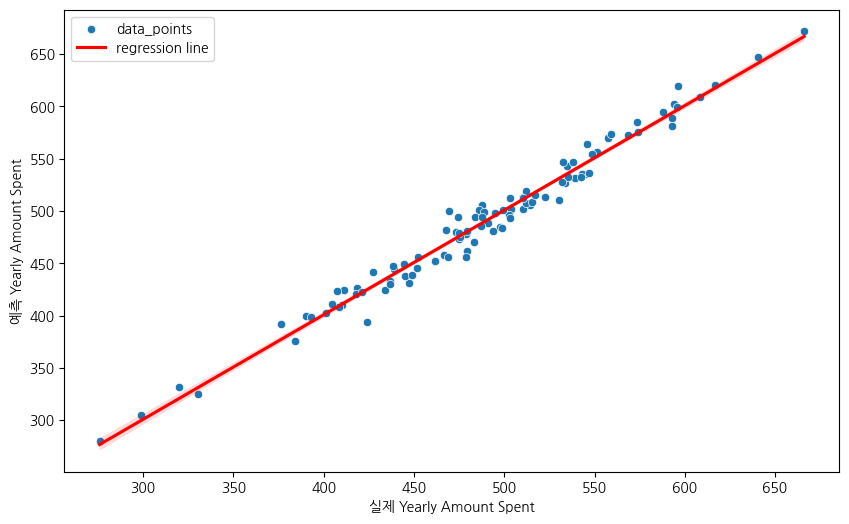

In [96]:
# 산점도와 회귀선 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=pred, label='data_points')
sns.regplot(x=y_test, y=pred, scatter=False, label="regression line", color='red')
plt.xlabel("실제 Yearly Amount Spent")
plt.ylabel("예측 Yearly Amount Spent")
plt.legend()
plt.show()

## R 문법으로 statsmodels 회귀분석하기

In [97]:
# import statsmodels.api as sm   - python 방식
from statsmodels.formula.api import ols

In [36]:
train_data = pd.concat([X_train, y_train], axis=1)
train_data

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
249,0.728756,-0.140376,-0.173216,0.065197,518.786483
433,1.233670,-0.235492,-0.700765,-1.413095,434.144202
19,-0.449465,1.935961,0.166982,0.483620,605.061039
322,0.206170,-1.328388,-0.860896,0.505068,478.262126
332,0.084123,-0.321354,0.899668,-1.342230,424.202827
...,...,...,...,...,...
106,-0.780032,0.133039,-0.854333,0.208220,494.551861
270,0.958189,0.900460,1.607973,-0.284756,540.995739
348,-1.265871,-1.173271,-2.088751,-0.428040,392.810345
435,-0.812250,2.079565,0.002649,0.188979,571.216005


In [37]:
test_data = pd.concat([X_test, y_test], axis=1)
test_data

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
361,-0.997132,-1.713455,1.991749,-0.130046,401.033135
73,-0.256010,0.761003,0.010579,0.276169,534.777188
374,-1.635907,-1.960221,1.006187,0.652866,418.602742
155,-0.620106,1.402969,0.214506,-0.610417,503.978379
104,-1.694561,-1.065741,1.036687,-0.135598,410.069611
...,...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081,593.156401
86,0.827716,0.460923,0.129021,-0.874853,487.379306
75,-1.025263,0.180722,1.682520,-0.435901,478.719357
438,-0.924682,-2.014653,0.158072,-0.032122,392.992256


In [38]:
train_data.columns = ['AvgSessionLength', 'TimeonApp', 'TimeonWebsite',
       'LengthofMembership', 'YearlyAmountSpent']
train_data.columns

Index(['AvgSessionLength', 'TimeonApp', 'TimeonWebsite', 'LengthofMembership',
       'YearlyAmountSpent'],
      dtype='object')

In [39]:
test_data.columns = ['AvgSessionLength', 'TimeonApp', 'TimeonWebsite',
       'LengthofMembership', 'YearlyAmountSpent']
test_data.columns

Index(['AvgSessionLength', 'TimeonApp', 'TimeonWebsite', 'LengthofMembership',
       'YearlyAmountSpent'],
      dtype='object')

In [40]:
"+".join(train_data.columns[:-1])

'AvgSessionLength+TimeonApp+TimeonWebsite+LengthofMembership'

In [41]:
model = ols('YearlyAmountSpent ~ ' + "+".join(train_data.columns[:-1]) , data=train_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      YearlyAmountSpent   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     6676.
Date:                Thu, 08 May 2025   Prob (F-statistic):               0.00
Time:                        07:01:25   Log-Likelihood:                -1480.1
No. Observations:                 400   AIC:                             2970.
Df Residuals:                     395   BIC:                             2990.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            501.9922      0

In [42]:
model = ols('YearlyAmountSpent ~ AvgSessionLength + TimeonApp + TimeonWebsite + LengthofMembership', data=train_data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      YearlyAmountSpent   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     6676.
Date:                Thu, 08 May 2025   Prob (F-statistic):               0.00
Time:                        07:01:25   Log-Likelihood:                -1480.1
No. Observations:                 400   AIC:                             2970.
Df Residuals:                     395   BIC:                             2990.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            501.9922      0

# 사이킷런을 이용한 회귀분석

In [98]:
from sklearn.linear_model import LinearRegression

In [99]:
X_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,-0.997132,-1.713455,1.991749,-0.130046
73,-0.256010,0.761003,0.010579,0.276169
374,-1.635907,-1.960221,1.006187,0.652866
155,-0.620106,1.402969,0.214506,-0.610417
104,-1.694561,-1.065741,1.036687,-0.135598
...,...,...,...,...
347,0.718270,-0.754847,0.800082,1.529081
86,0.827716,0.460923,0.129021,-0.874853
75,-1.025263,0.180722,1.682520,-0.435901
438,-0.924682,-2.014653,0.158072,-0.032122


In [101]:
slr = LinearRegression()
slr.fit(X_train, y_train)
pred3 = slr.predict(X_test)
print("mse:  ", mean_squared_error(y_test, pred3))
print("rmse:  ", np.sqrt(mean_squared_error(y_test, pred3)))

mse:   109.86374118394029
rmse:   10.48159058463649


In [102]:
# y절편
print("y절편: ", slr.intercept_)

y절편:  501.9921512124531


In [103]:
print("각 변수의 회귀 계수: ", slr.coef_)

각 변수의 회귀 계수:  [25.25038131 38.70350139  0.31546926 63.54321107]


In [104]:
print("각 변수의 이름: ", slr.feature_names_in_)

각 변수의 이름:  ['Avg. Session Length' 'Time on App' 'Time on Website'
 'Length of Membership']


In [105]:
model_coef = pd.DataFrame(dict(feature=slr.feature_names_in_, coef=slr.coef_))
model_coef

,feature,coef
0,Avg. Session Length,25.250381
1,Time on App,38.703501
2,Time on Website,0.315469
3,Length of Membership,63.543211


 $ R^2 $ 값 출력하기

In [106]:
r2 = slr.score(X_test, y_test)
print("r2: ", r2)

r2:  0.9778130629184126


In [107]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred3))
result

,y_test,pred
361,401.033135,402.862301
73,534.777188,542.533257
374,418.602742,426.620119
155,503.978379,501.913864
104,410.069611,409.666655
...,...,...
347,593.156401,588.328629
86,487.379306,485.181373
75,478.719357,455.930701
438,392.992256,398.678207


In [109]:
result['편차'] = result['y_test'] - result['pred']
result.head(60)

,y_test,pred,편차
361,401.033135,402.862301,-1.829165
73,534.777188,542.533257,-7.756069
374,418.602742,426.620119,-8.017377
155,503.978379,501.913864,2.064515
104,410.069611,409.666655,0.402956
394,557.608262,569.921550,-12.313288
377,538.941975,531.504235,7.437739
124,514.336558,505.943092,8.393466
68,408.620188,408.103786,0.516402
450,475.015407,473.459429,1.555978


In [110]:
result['편차제곱'] = result['편차'] ** 2 
result

,y_test,pred,편차,편차제곱
361,401.033135,402.862301,-1.829165,3.345846
73,534.777188,542.533257,-7.756069,60.156606
374,418.602742,426.620119,-8.017377,64.278335
155,503.978379,501.913864,2.064515,4.262224
104,410.069611,409.666655,0.402956,0.162374
...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383
86,487.379306,485.181373,2.197933,4.830911
75,478.719357,455.930701,22.788656,519.322841
438,392.992256,398.678207,-5.685951,32.330042


In [111]:
result['루트편차제곱'] = result['편차제곱'].apply(np.sqrt)
result

,y_test,pred,편차,편차제곱,루트편차제곱
361,401.033135,402.862301,-1.829165,3.345846,1.829165
73,534.777188,542.533257,-7.756069,60.156606,7.756069
374,418.602742,426.620119,-8.017377,64.278335,8.017377
155,503.978379,501.913864,2.064515,4.262224,2.064515
104,410.069611,409.666655,0.402956,0.162374,0.402956
...,...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383,4.827772
86,487.379306,485.181373,2.197933,4.830911,2.197933
75,478.719357,455.930701,22.788656,519.322841,22.788656
438,392.992256,398.678207,-5.685951,32.330042,5.685951


In [112]:
result['평균편차제곱_MSE'] = result['편차제곱'].mean()
result

,y_test,pred,편차,편차제곱,루트편차제곱,평균편차제곱_MSE
361,401.033135,402.862301,-1.829165,3.345846,1.829165,109.863741
73,534.777188,542.533257,-7.756069,60.156606,7.756069,109.863741
374,418.602742,426.620119,-8.017377,64.278335,8.017377,109.863741
155,503.978379,501.913864,2.064515,4.262224,2.064515,109.863741
104,410.069611,409.666655,0.402956,0.162374,0.402956,109.863741
...,...,...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383,4.827772,109.863741
86,487.379306,485.181373,2.197933,4.830911,2.197933,109.863741
75,478.719357,455.930701,22.788656,519.322841,22.788656,109.863741
438,392.992256,398.678207,-5.685951,32.330042,5.685951,109.863741


In [113]:
result['루트평균편차제곱_RMSE'] = result['평균편차제곱_MSE'].apply(np.sqrt)
result

,y_test,pred,편차,편차제곱,루트편차제곱,평균편차제곱_MSE,루트평균편차제곱_RMSE
361,401.033135,402.862301,-1.829165,3.345846,1.829165,109.863741,10.481591
73,534.777188,542.533257,-7.756069,60.156606,7.756069,109.863741,10.481591
374,418.602742,426.620119,-8.017377,64.278335,8.017377,109.863741,10.481591
155,503.978379,501.913864,2.064515,4.262224,2.064515,109.863741,10.481591
104,410.069611,409.666655,0.402956,0.162374,0.402956,109.863741,10.481591
...,...,...,...,...,...,...,...
347,593.156401,588.328629,4.827772,23.307383,4.827772,109.863741,10.481591
86,487.379306,485.181373,2.197933,4.830911,2.197933,109.863741,10.481591
75,478.719357,455.930701,22.788656,519.322841,22.788656,109.863741,10.481591
438,392.992256,398.678207,-5.685951,32.330042,5.685951,109.863741,10.481591
